In [19]:
# Cell 1: Master Control & Environment Setup
import sys
import subprocess
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

# 1. Consolidated Dependency Injection
packages = [
    "polars", "sqlalchemy", "tqdm", "ipython", 
    "rapidfuzz", "pyarrow>=8.0.0", "pandas", 
    "sentence-transformers", "torch", "torchvision", "torchaudio",
    "matplotlib", "seaborn", "xlsxwriter"
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U"] + packages)

# 2. Enable Auto-Reload
%load_ext autoreload
%autoreload 2

# 3. Path Resolution
from pathlib import Path
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

# 4. Global Imports
import gc
import torch
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sqlalchemy import select
from IPython.display import display, Markdown

# 5. Local Module Imports
from storage.db import get_engine, get_session_factory, init_db, SourceDocument, ProgramElement, FundingLine
from storage.ingest_r1 import R1Ingestor
from matching.fuzzy_matcher import ProgramMatcher
from matching.semantic_matcher import SemanticMatcher
from analysis.program_linker import ProgramLinker
from analysis.gap_analyzer import GapAnalyzer
from analysis.trend_tracker import TrendTracker
from analysis.report_generator import ExcelReportGenerator

# 6. Global Pipeline Configuration
CONFIG = {
    "DB_PATH": "sqlite:///../data/processed/usg_budgets.db",
    "PARQUET_PATH": "../data/processed/r1_all_years.parquet",
    "REPORT_DIR": "../data/processed",
    "REPORT_NAME": "DoD_Budget_Analysis.xlsx",
    "GAP_BASE_FY": 2023,    #<-- Gaps are most useful across one or two FYs
    "GAP_BUDGET_FY": 2025,
    "TREND_START_FY": 2010, #<-- Trends are more meaningful with 3+ years of data, so this can be set to a larger timeframe up to 1998.
    "TREND_END_FY": 2025,
    "FUZZY_THRESHOLD": 90.0,
    "SEMANTIC_THRESHOLD": 0.45
}

# 7. Global Infrastructure Initialization
engine = get_engine(CONFIG["DB_PATH"])
init_db(engine)
SessionFactory = get_session_factory(engine)

sns.set_theme(style="whitegrid", context="talk")
logging.info("Master environment, configuration, and database connections initialized.")

INFO: Master environment, configuration, and database connections initialized.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# Cell 2: Database Initialization & Ingestion
# Note: Safe to skip if the SQLite database is already fully populated.
parquet_file = Path(CONFIG["PARQUET_PATH"])

if not parquet_file.exists():
    display(Markdown(f"**CRITICAL ERROR:** Parquet file missing at `{parquet_file}`. Halt execution."))
else:
    with SessionFactory() as session:
        # Idempotent load: clear existing target tables
        session.query(FundingLine).delete()
        session.query(ProgramElement).delete()
        session.query(SourceDocument).delete()
        session.commit()
        
        ingestor = R1Ingestor(session)
        ingestor.ingest_parquet(str(parquet_file))

INFO: Loading data from ..\data\processed\r1_all_years.parquet
Processing rows: 100%|██████████| 19700/19700 [00:05<00:00, 3586.54it/s]
INFO: Inserting 52598 funding records...
INFO: Ingestion complete.


In [21]:
# Cell 3: Execute Waterfall Linker
# In a production scenario, these queries would be dynamically loaded from a CSV/DB of public statements.
unstructured_queries = [
    "Next Generation Air Dominance Fighter",
    "JADC2 Cloud Infrastructure",            
    "Hypersonic Glide Body Prototype",       
    "Procurement of Office Supplies",        
    "",                                      
    "Abrams Tank Upgrade"                    
]

with SessionFactory() as session:
    try:
        fuzzy_matcher = ProgramMatcher(session)
        semantic_matcher = SemanticMatcher(session)
        
        linker = ProgramLinker(
            fuzzy_matcher=fuzzy_matcher,
            semantic_matcher=semantic_matcher,
            fuzzy_threshold=CONFIG["FUZZY_THRESHOLD"],
            semantic_threshold=CONFIG["SEMANTIC_THRESHOLD"]
        )
        
        df_linked = linker.link_batch(unstructured_queries)
        
        display(Markdown("### Waterfall Linker Results"))
        display(df_linked.to_pandas(use_pyarrow_extension_array=True))

    except Exception as e:
        print(f"Pipeline execution failed: {e}")
        
    finally:
        # Free memory of PyTorch models immediately after linking is complete.
        if 'linker' in locals(): del linker
        if 'fuzzy_matcher' in locals(): del fuzzy_matcher
        if 'semantic_matcher' in locals(): del semantic_matcher
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        elif torch.backends.mps.is_available(): torch.mps.empty_cache()

INFO: Loaded 2088 Program Elements into matcher memory.
INFO: Initializing SemanticMatcher on device: cpu
INFO: Load pretrained SentenceTransformer: multi-qa-MiniLM-L6-cos-v1
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/b207367332321f8e44f96e224ef15bc607f4dbf0/modules.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/b207367332321f8e44f96e224ef15bc607f4dbf0/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/multi-qa-MiniLM

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/b207367332321f8e44f96e224ef15bc607f4dbf0/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/b207367332321f8e44f96e224ef15bc607f4dbf0/

Batches:   0%|          | 0/66 [00:00<?, ?it/s]

INFO: Vector space initialization complete.
Linking Programs:   0%|          | 0/6 [00:00<?, ?query/s]

...

Linking Programs:  67%|██████▋   | 4/6 [00:00<00:00, 25.79query/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Linking Programs: 100%|██████████| 6/6 [00:00<00:00, 31.60query/s]


### Waterfall Linker Results

,query,matched_pe_id,matched_name,match_strategy,confidence_score
0,Next Generation Air Dominance Fighter,1230,Next Generation Air Dominance,FUZZY,95.0
1,JADC2 Cloud Infrastructure,1995,JADC2 Development and Experimentation Activities,SEMANTIC,0.642
2,Hypersonic Glide Body Prototype,1559,Hypersonics Prototyping,SEMANTIC,0.7
3,Procurement of Office Supplies,511,Information Technology Development-Standard Pr...,SEMANTIC,0.606
4,,<NA>,INVALID_INPUT,NONE,0.0
5,Abrams Tank Upgrade,1451,Armored System Modernization - Adv Dev,SEMANTIC,0.491


In [22]:
# Cell 4: Execute Analytical Engines
if 'df_linked' not in locals():
    raise RuntimeError("Missing required state: 'df_linked'. Please execute Cell 3 (Waterfall Linker) first.")

with SessionFactory() as session:
    try:
        gap_analyzer = GapAnalyzer(session)
        df_gaps = gap_analyzer.analyze_gaps(
            df_linked=df_linked, 
            base_year=CONFIG["GAP_BASE_FY"], 
            budget_year=CONFIG["GAP_BUDGET_FY"]
        )
        
        trend_tracker = TrendTracker(session)
        df_trends = trend_tracker.get_agency_trends(
            start_year=CONFIG["TREND_START_FY"], end_year=CONFIG["TREND_END_FY"]
        )
        
        # NEW: Generate Granular PE Trends
        df_pe_trends = trend_tracker.get_pe_trends(
            start_year=CONFIG["TREND_START_FY"], end_year=CONFIG["TREND_END_FY"]
        )
        
        display(Markdown("### Analytical Generation Complete"))
        display(Markdown(f"- Generated Gap Analysis: `{df_gaps.height}` records."))
        display(Markdown(f"- Generated Macro Trends: `{df_trends.height}` agencies."))
        display(Markdown(f"- Generated PE Trends: `{df_pe_trends.height}` program elements."))

    except Exception as e:
        print(f"Analysis execution failed: {e}")

### Analytical Generation Complete

- Generated Gap Analysis: `6` records.

- Generated Macro Trends: `6` agencies.

- Generated PE Trends: `1865` program elements.

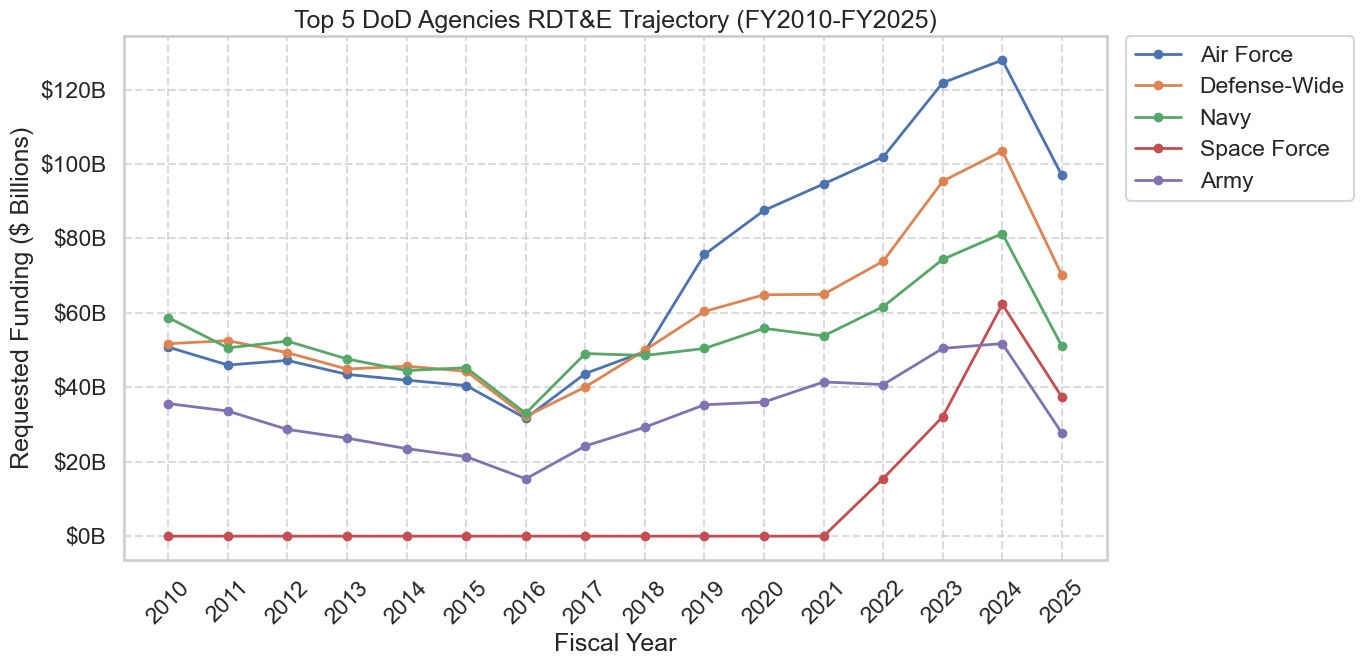

In [23]:
# Cell 5: Render Executive Visualizations (Optimized for 10-15 Year Windows)
if 'df_trends' not in locals() or df_trends.is_empty():
    display(Markdown("*No trend data available for visualization. Run Cell 4.*"))
else:
    df_top5 = df_trends.head(5).to_pandas()
    
    start, end = CONFIG["TREND_START_FY"], CONFIG["TREND_END_FY"]
    years_str = [str(y) for y in range(start, end + 1) if str(y) in df_top5.columns]
    years_int = [int(y) for y in years_str]
    
    # Expanded width to accommodate 15 data points on the x-axis
    plt.figure(figsize=(14, 7)) 
    
    for index, row in df_top5.iterrows():
        plt.plot(
            years_int, 
            row[years_str].values / 1_000_000, 
            marker='o', 
            markersize=6,
            linewidth=2, 
            label=row['agency']
        )
    
    plt.title(f'Top 5 DoD Agencies RDT&E Trajectory (FY{start}-FY{end})')
    plt.xlabel('Fiscal Year')
    plt.ylabel('Requested Funding ($ Billions)')
    
    # Optimization: Force integer ticks and rotate 45 degrees to prevent collision
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.xticks(rotation=45) 
    
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}B'))
    
    plt.grid(True, which='major', axis='both', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

In [24]:
# Cell 6: Execute Excel Serialization & Terminal Cleanup
try:
    if 'df_gaps' not in locals() or 'df_trends' not in locals() or 'df_pe_trends' not in locals():
        raise ValueError("DataFrames not found in memory. Ensure Cells 3 and 4 completed successfully.")

    report_gen = ExcelReportGenerator(output_dir=CONFIG["REPORT_DIR"])
    
    # Scale percentage columns for Excel native formatting
    df_trends_export = df_trends.with_columns(
        (pl.col("total_delta_pct") / 100).alias("total_delta_pct"),
        (pl.col("cagr_pct") / 100).alias("cagr_pct")
    )
    
    df_pe_trends_export = df_pe_trends.with_columns(
        (pl.col("total_delta_pct") / 100).alias("total_delta_pct"),
        (pl.col("cagr_pct") / 100).alias("cagr_pct")
    )
    
    df_gaps_export = df_gaps.with_columns(
        (pl.col("YoY_Change_%") / 100).alias("YoY_Change_%")
    )

    output_file = report_gen.generate_executive_report(
        df_gaps=df_gaps_export,
        df_trends=df_trends_export,
        df_pe_trends=df_pe_trends_export,
        filename=CONFIG["REPORT_NAME"]
    )
    
    display(Markdown(f"### Pipeline Complete. Export Successful."))
    display(Markdown(f"**Report Path:** `{output_file}`"))

except PermissionError:
    print("Export failed: Target Excel file is open. Close it and retry.")
except Exception as e:
    print(f"Export execution failed: {e}")
    
finally:
    logging.info("Executing final memory flush...")
    vars_to_delete = [
        'report_gen', 'df_trends_export', 'df_gaps_export', 'df_pe_trends_export',
        'df_trends', 'df_gaps', 'df_pe_trends', 'df_linked', 'gap_analyzer', 'trend_tracker'
    ]
    for var in vars_to_delete:
        if var in locals():
            del locals()[var]
    
    import gc
    gc.collect()

INFO: Report successfully generated at: g:\My Drive\Programming\Python\USG Budget Analyzer\dod_ic_budget_analyzer\notebooks\..\data\processed\DoD_Budget_Analysis.xlsx


### Pipeline Complete. Export Successful.

**Report Path:** `g:\My Drive\Programming\Python\USG Budget Analyzer\dod_ic_budget_analyzer\notebooks\..\data\processed\DoD_Budget_Analysis.xlsx`

INFO: Executing final memory flush...
